In [1]:
!pip install transformers torch pandas numpy scikit-learn itables matplotlib scipy

import os
import io
import copy
import json
import random

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itables import show
from scipy.stats import kendalltau

import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from google.colab import drive, files

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 36.4 MB/s eta 0:00:00


In [2]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Update this path to the folder containing your data files (CSV and NPY)
folder_path = '/content/drive/MyDrive/my_data_folder/'

X_train_path = os.path.join(folder_path, 'X_train.csv')
X_test_path = os.path.join(folder_path, 'X_test.csv')
X_val_path = os.path.join(folder_path, 'X_val.csv')
y_train_path = os.path.join(folder_path, 'y_train.csv')
y_test_path = os.path.join(folder_path, 'y_test.csv')
y_val_path = os.path.join(folder_path, 'y_val.csv')

E1_train_path = os.path.join(folder_path, 'E1_train.npy')
E2_train_path = os.path.join(folder_path, 'E2_train.npy')
E1_test_path = os.path.join(folder_path, 'E1_test.npy')
E2_test_path = os.path.join(folder_path, 'E2_test.npy')
E1_val_path = os.path.join(folder_path, 'E1_val.npy')
E2_val_path = os.path.join(folder_path, 'E2_val.npy')

print(f"Data paths set. Checking if files exist...")
all_file_paths = [
    X_train_path, X_test_path, X_val_path,
    y_train_path, y_test_path, y_val_path,
    E1_train_path, E2_train_path, E1_test_path,
    E2_test_path, E1_val_path, E2_val_path
]
for f in all_file_paths:
    print(f"{f}: {'Found' if os.path.exists(f) else 'Not Found'}")

Mounted at /content/drive
Data paths set. Checking if files exist...
/content/drive/MyDrive/my_data_folder/X_train.csv: Found
/content/drive/MyDrive/my_data_folder/X_test.csv: Found
/content/drive/MyDrive/my_data_folder/X_val.csv: Found
/content/drive/MyDrive/my_data_folder/y_train.csv: Found
/content/drive/MyDrive/my_data_folder/y_test.csv: Found
/content/drive/MyDrive/my_data_folder/y_val.csv: Found
/content/drive/MyDrive/my_data_folder/E1_train.npy: Found
/content/drive/MyDrive/my_data_folder/E2_train.npy: Found
/content/drive/MyDrive/my_data_folder/E1_test.npy: Found
/content/drive/MyDrive/my_data_folder/E2_test.npy: Found
/content/drive/MyDrive/my_data_folder/E1_val.npy: Found
/content/drive/MyDrive/my_data_folder/E2_val.npy: Found


In [3]:
SEED = 101
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
TARGET_VARIABLE = "Mole fraction"

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [5]:
# X_train = pd.read_csv("X_train.csv")
# X_test = pd.read_csv("X_test.csv")
# X_val = pd.read_csv("X_val.csv")
# y_train = pd.read_csv("y_train.csv")
# y_test = pd.read_csv("y_test.csv")
# y_val = pd.read_csv("y_val.csv")

X_train = pd.read_csv(X_train_path)
X_test = pd.read_csv(X_test_path)
X_val = pd.read_csv(X_val_path)
y_train = pd.read_csv(y_train_path)
y_test = pd.read_csv(y_test_path)
y_val = pd.read_csv(y_val_path)

In [6]:
X_train.drop(
    columns=["Component 1", "Component 2", "mol1", "mol2"],
    inplace=True
)
X_test.drop(
    columns=["Component 1", "Component 2", "mol1", "mol2"],
    inplace=True
)
X_val.drop(
    columns=["Component 1", "Component 2", "mol1", "mol2"],
    inplace=True
)

In [7]:
#show(X_train.head())

In [8]:
X_train.columns.get_loc("('BalabanJ', <class 'numpy.float64'>)")
X_train.columns.get_loc("('BalabanJ', <class 'numpy.float64'>).1")

205

In [9]:
def separate_features(X):
    return X.iloc[:, 0:3], X.iloc[:, 3:5], X.iloc[:, 5:205], X.iloc[:, 205:405], X.iloc[:, 405:430], X.iloc[:, 430:]
# property_T_P, SMILES, Component 1 Descriptors, Component 2 Descriptors, Property category, phase

In [10]:
X_train_prop, X_train_smiles, X_train_comp1_desc, X_train_comp2_desc, X_train_prop_cat, X_train_phase = separate_features(X_train)
X_test_prop, X_test_smiles, X_test_comp1_desc, X_test_comp2_desc, X_test_prop_cat, X_test_phase = separate_features(X_test)
X_val_prop, X_val_smiles, X_val_comp1_desc, X_val_comp2_desc, X_val_prop_cat, X_val_phase = separate_features(X_val)

In [11]:
#show(X_train_phase.head())

In [12]:
# E1_train = np.load("E1_train.npy")
# E2_train = np.load("E2_train.npy")
# E1_test = np.load("E1_test.npy")
# E2_test = np.load("E2_test.npy")
# E1_val = np.load("E1_val.npy")
# E2_val = np.load("E2_val.npy")
E1_train = np.load(E1_train_path)
E2_train = np.load(E2_train_path)
E1_test = np.load(E1_test_path)
E2_test = np.load(E2_test_path)
E1_val = np.load(E1_val_path)
E2_val = np.load(E2_val_path)

In [13]:
class RDKitEncoder(nn.Module):
    def __init__(self, input_dim=200, embed_dim=128, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, embed_dim),
            nn.BatchNorm1d(embed_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

In [14]:
class MixtureFusion(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.linear = nn.Linear(dim * 2, dim)

    def forward(self, e1, e2):
        # Symmetric average then project
        combined = (torch.cat([e1, e2], dim=-1) + torch.cat([e2, e1], dim=-1)) / 2
        return self.linear(combined)

In [15]:
class MultiModalNet(nn.Module):
    def __init__(self,
                 smiles_dim=512,      # SMOLE-BERT output dim
                 rdkit_dim=200,       # RDKit features per component
                 rdkit_embed_dim=128, # RDKit encoder output dim
                 tabular_dim=30,    # T, P, Physics features — set this to your actual count
                 fusion_dim=256,      # projection dim for SMILES fusion
                 hidden_dim=256,
                 dropout=0.2):
        super().__init__()

        # SMILES projection + fusion
        self.smiles_proj = nn.Linear(smiles_dim, fusion_dim)
        self.smiles_fusion = MixtureFusion(fusion_dim)

        # RDKit encoder (shared) + fusion
        self.rdkit_enc = RDKitEncoder(input_dim=rdkit_dim, embed_dim=rdkit_embed_dim, dropout=dropout)
        self.rdkit_fusion = MixtureFusion(rdkit_embed_dim)

        # Predictor MLP
        combined_dim = fusion_dim + rdkit_embed_dim + tabular_dim
        self.predictor = nn.Sequential(
        nn.Linear(combined_dim, hidden_dim),
        nn.BatchNorm1d(hidden_dim),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(hidden_dim, hidden_dim),
        nn.BatchNorm1d(hidden_dim),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(hidden_dim, hidden_dim // 2),
        nn.BatchNorm1d(hidden_dim // 2),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(hidden_dim // 2, 1),
        nn.Hardtanh(min_val=0.0, max_val=1.0)
        )

    def forward(self, smiles_e1, smiles_e2, rdkit_x1, rdkit_x2, tabular):
        # SMILES stream
        e1 = self.smiles_proj(smiles_e1)
        e2 = self.smiles_proj(smiles_e2)
        s  = self.smiles_fusion(e1, e2)

        # RDKit stream
        r1 = self.rdkit_enc(rdkit_x1)
        r2 = self.rdkit_enc(rdkit_x2)
        x  = self.rdkit_fusion(r1, r2)

        # Concatenate all streams + tabular
        fused = torch.cat([s, x, tabular], dim=-1)

        return self.predictor(fused)

In [16]:
# Tabular: concatenate prop + prop_cat + phase
tabular_train = np.concatenate([X_train_prop, X_train_prop_cat, X_train_phase], axis=1)
tabular_val   = np.concatenate([X_val_prop,   X_val_prop_cat,   X_val_phase],   axis=1)
tabular_test  = np.concatenate([X_test_prop,  X_test_prop_cat,  X_test_phase],  axis=1)



In [17]:
class MultiModalDataset(Dataset):
    def __init__(self, E1, E2, X1, X2, tabular, y):
        self.E1      = torch.tensor(E1, dtype=torch.float32)
        self.E2      = torch.tensor(E2, dtype=torch.float32)
        self.X1      = torch.tensor(np.array(X1), dtype=torch.float32)
        self.X2      = torch.tensor(np.array(X2), dtype=torch.float32)
        self.tabular = torch.tensor(np.array(tabular), dtype=torch.float32)
        self.y       = torch.tensor(np.array(y), dtype=torch.float32).squeeze()

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.E1[idx], self.E2[idx], self.X1[idx], self.X2[idx], self.tabular[idx], self.y[idx]

In [18]:
X1_train, X2_train = X_train_comp1_desc, X_train_comp2_desc
X1_val,   X2_val   = X_val_comp1_desc,   X_val_comp2_desc
X1_test,  X2_test  = X_test_comp1_desc,  X_test_comp2_desc

train_dataset = MultiModalDataset(E1_train, E2_train, X1_train, X2_train, tabular_train, y_train)
val_dataset   = MultiModalDataset(E1_val,   E2_val,   X1_val,   X2_val,   tabular_val,   y_val)

train_loader = DataLoader(train_dataset, batch_size=2048, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=2048)

In [19]:
model = MultiModalNet(
    smiles_dim=512,         # Changed from 768 to 512 to match input data
    rdkit_dim=200,
    rdkit_embed_dim=128,
    tabular_dim=tabular_train.shape[1],
    fusion_dim=256,
    hidden_dim=256,
    dropout=0.2
).to(device)

In [21]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
best_val_loss = float('inf')
best_model_state = None

n_epochs = 500
for epoch in range(n_epochs):
    model.train()
    train_losses = []
    for E1, E2, X1, X2, tab, y_batch in train_loader:
        E1, E2, X1, X2, tab, y_batch = [t.to(device) for t in [E1, E2, X1, X2, tab, y_batch]]
        optimizer.zero_grad()
        y_pred = model(E1, E2, X1, X2, tab)
        loss = criterion(y_pred.squeeze(), y_batch)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_losses = []
        for E1, E2, X1, X2, tab, y_batch in val_loader:
            E1, E2, X1, X2, tab, y_batch = [t.to(device) for t in [E1, E2, X1, X2, tab, y_batch]]
            val_losses.append(criterion(model(E1, E2, X1, X2, tab).squeeze(), y_batch).item())

    val_loss = np.mean(val_losses)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{n_epochs} — Train MSE: {np.mean(train_losses):.4f} — Val MSE: {val_loss:.4f}")

Epoch 10/500 — Train MSE: 0.0526 — Val MSE: 0.0508
Epoch 20/500 — Train MSE: 0.0429 — Val MSE: 0.0477
Epoch 30/500 — Train MSE: 0.0414 — Val MSE: 0.0444
Epoch 40/500 — Train MSE: 0.0361 — Val MSE: 0.0398
Epoch 50/500 — Train MSE: 0.0355 — Val MSE: 0.0376
Epoch 60/500 — Train MSE: 0.0342 — Val MSE: 0.0383
Epoch 70/500 — Train MSE: 0.0343 — Val MSE: 0.0378
Epoch 80/500 — Train MSE: 0.0335 — Val MSE: 0.0386
Epoch 90/500 — Train MSE: 0.0334 — Val MSE: 0.0372
Epoch 100/500 — Train MSE: 0.0332 — Val MSE: 0.0376
Epoch 110/500 — Train MSE: 0.0333 — Val MSE: 0.0381
Epoch 120/500 — Train MSE: 0.0330 — Val MSE: 0.0368
Epoch 130/500 — Train MSE: 0.0337 — Val MSE: 0.0373
Epoch 140/500 — Train MSE: 0.0338 — Val MSE: 0.0376
Epoch 150/500 — Train MSE: 0.0337 — Val MSE: 0.0376
Epoch 160/500 — Train MSE: 0.0331 — Val MSE: 0.0370
Epoch 170/500 — Train MSE: 0.0338 — Val MSE: 0.0369
Epoch 180/500 — Train MSE: 0.0334 — Val MSE: 0.0367
Epoch 190/500 — Train MSE: 0.0334 — Val MSE: 0.0375
Epoch 200/500 — Train

In [26]:
torch.save({
    'model_state_dict': best_model_state,
    'best_val_loss': best_val_loss,
    'tabular_dim': tabular_train.shape[1],
}, 'multimodal.pth')

In [27]:
def evaluate_model(y_test, y_pred, show_plot=False, save_file=False, save_path="./results.json"):
    """Evaluate model performance given true and predicted values."""
    y_test = np.array(y_test).flatten()
    y_pred = np.array(y_pred).flatten()

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2  = r2_score(y_test, y_pred)
    tau = kendalltau(y_test, y_pred).correlation

    # Bootstrap CI
    rng = np.random.default_rng(101)
    mae_scores, mse_scores, r2_scores, tau_scores = [], [], [], []

    for _ in range(1000):
        idx = rng.integers(0, len(y_test), len(y_test))
        mae_scores.append(mean_absolute_error(y_test[idx], y_pred[idx]))
        mse_scores.append(mean_squared_error(y_test[idx], y_pred[idx]))
        r2_scores.append(r2_score(y_test[idx], y_pred[idx]))
        tau_scores.append(kendalltau(y_test[idx], y_pred[idx]).correlation)

    mae_std = np.std(mae_scores)
    mse_std = np.std(mse_scores)
    r2_std  = np.std(r2_scores)
    tau_std = np.std(tau_scores)

    mae_ci  = np.percentile(mae_scores, [2.5, 97.5])
    mse_ci  = np.percentile(mse_scores, [2.5, 97.5])
    r2_ci   = np.percentile(r2_scores,  [2.5, 97.5])
    tau_ci  = np.percentile(tau_scores, [2.5, 97.5])

    print(f"MAE          = {mae:.4f}, Std: {mae_std:.4f} (95% CI: {mae_ci[0]:.4f}–{mae_ci[1]:.4f})")
    print(f"MSE          = {mse:.4f}, Std: {mse_std:.4f} (95% CI: {mse_ci[0]:.4f}–{mse_ci[1]:.4f})")
    print(f"R²           = {r2:.4f}, Std: {r2_std:.4f} (95% CI: {r2_ci[0]:.4f}–{r2_ci[1]:.4f})")
    print(f"Kendall's τ  = {tau:.4f}, Std: {tau_std:.4f} (95% CI: {tau_ci[0]:.4f}–{tau_ci[1]:.4f})")

    if save_file:
        results = {"MAE": mae, "MSE": mse, "R2": r2, "Kendall_tau": tau}
        with open(save_path, "w") as f:
            json.dump(results, f)
        print(f"Results saved to {save_path}")

    if show_plot:
        plt.figure(figsize=(6, 6))
        plt.scatter(y_test, y_pred, alpha=0.1, s=10)
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", label="Perfect fit")
        plt.xlabel("Actual")
        plt.ylabel("Predicted")
        plt.title("Actual vs Predicted")
        plt.legend()
        plt.show()

MAE          = 0.1336, Std: 0.0013 (95% CI: 0.1311–0.1361)
MSE          = 0.0347, Std: 0.0006 (95% CI: 0.0336–0.0359)
R²           = 0.6354, Std: 0.0061 (95% CI: 0.6238–0.6475)
Kendall's τ  = 0.6038, Std: 0.0044 (95% CI: 0.5953–0.6123)


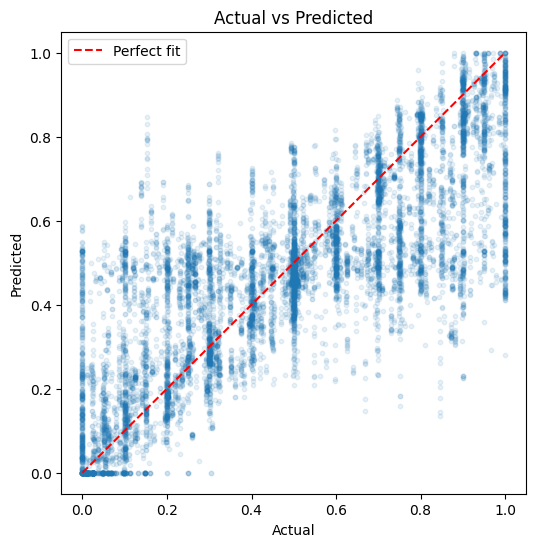

In [28]:
# Restore best weights
model.load_state_dict(best_model_state)

model.eval()
with torch.no_grad():
    E1_t = torch.tensor(E1_test, dtype=torch.float32).to(device)
    E2_t = torch.tensor(E2_test, dtype=torch.float32).to(device)
    X1_t = torch.tensor(np.array(X1_test), dtype=torch.float32).to(device)
    X2_t = torch.tensor(np.array(X2_test), dtype=torch.float32).to(device)
    tab_t = torch.tensor(tabular_test, dtype=torch.float32).to(device)
    y_pred = model(E1_t, E2_t, X1_t, X2_t, tab_t).cpu().numpy().flatten()

evaluate_model(y_test, y_pred, show_plot=True)

In [29]:
import shutil

# List of files to save
files_to_save = ["multimodal.pth"]

# Copy each file to your specified Google Drive folder
for f in files_to_save:
    if os.path.exists(f):
        shutil.copy(f, os.path.join(folder_path, f))
        print(f"Saved {f} to {folder_path}")
    else:
        print(f"File {f} not found in local storage.")

Saved multimodal.pth to /content/drive/MyDrive/my_data_folder/
